# Tutorial: MLP para clasificacion con CIFAR-10 (Keras)

En este cuaderno entrenaremos dos modelos MLP (perceptron multicapa) para clasificacion de imagenes en CIFAR-10:

1. Modelo base sin regularizacion.
2. Modelo con regularizacion (L2 + Dropout + BatchNormalization + EarlyStopping).

Compararemos:
- Curvas de entrenamiento y test (accuracy y loss).
- Matriz de confusion.
- Metricas tipicas de evaluacion.


In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt

# importo las librerías necesarias para el preprocesamiento de datos y la construcción del modelo
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)

import keras # importo keras
from keras import layers, regularizers # importo los regularizadores de keras

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
keras.utils.set_random_seed(SEED)

print("Keras version:", keras.__version__)
print("Backend activo:", keras.backend.backend())


Keras version: 2.14.0
Backend activo: tensorflow


In [2]:
# Cargar CIFAR-10
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data() # esto está incluido en keras

y_train = y_train.squeeze()
y_test = y_test.squeeze()

class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

print("x_train:", x_train.shape, "y_train:", y_train.shape) # he cargado 50000 imágenes, con 32x32 píxeles y 3 canales de color (RGB)
print("x_test :", x_test.shape, "y_test :", y_test.shape)


x_train: (50000, 32, 32, 3) y_train: (50000,)
x_test : (10000, 32, 32, 3) y_test : (10000,)


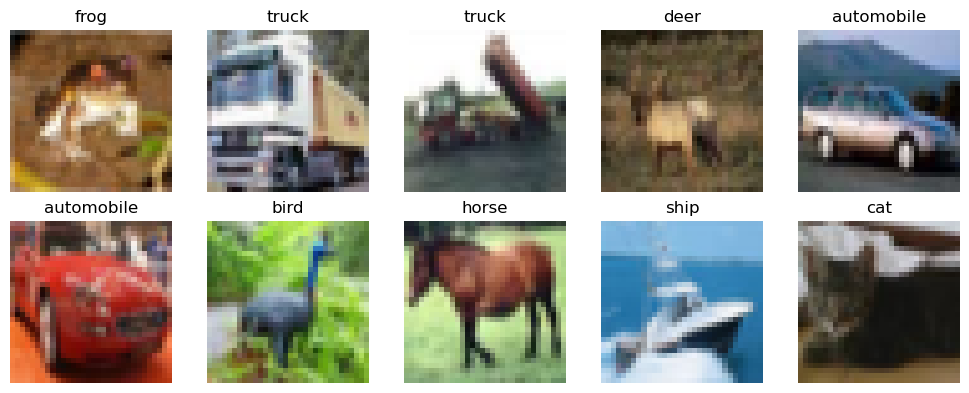

In [ ]:
# Visualizar algunas imagenes del dataset
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i]])
    plt.axis("off")
plt.tight_layout()
plt.show()
# aparecen 10 clases diferentes, con imágenes de 32x32 píxeles y 3 canales de color (RGB)
# dataset absurdo solo para enseñarlos el ejemplo


In [ ]:
# Preprocesado para MLP: normalizar y aplanar
x_train_mlp = x_train.astype("float32") / 255.0 # normalizamos, cómo hemos hecho antes con MNIST, pero ahora con CIFAR-10. Lo paso a float32 para ahorrar memoria.
x_test_mlp = x_test.astype("float32") / 255.0

x_train_mlp = x_train_mlp.reshape(len(x_train_mlp), -1) # aquí aplanamos a través del reshape. Siempre muy útil para poder hacer un aplanamiento. El -1 le dice a numpy que calcule automáticamente el tamaño de esa dimensión en función del número total de elementos y el tamaño de la otra dimensión. En este caso, cada imagen de 32x32 píxeles con 3 canales (RGB) se convierte en un vector de 3072 elementos (32*32*3 = 3072).
x_test_mlp = x_test_mlp.reshape(len(x_test_mlp), -1)

input_dim = x_train_mlp.shape[1]
num_classes = 10

print("Input dimension para MLP:", input_dim) # Ahora vemos que cada dato tiene 3072, que son todos los píxeles de la imagen aplanados (32x32x3 = 3072)
print("Número de clases:", num_classes)



Input dimension para MLP: 3072


## Utilidades para entrenamiento y evaluacion


In [ ]:
def plot_history(history, title):
    hist = history.history
    epochs = range(1, len(hist["loss"]) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs, hist["loss"], label="train loss")
    axes[0].plot(epochs, hist["val_loss"], label="test loss")
    axes[0].set_title(f"{title} - Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs, hist["accuracy"], label="train acc")
    axes[1].plot(epochs, hist["val_accuracy"], label="test acc")
    axes[1].set_title(f"{title} - Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def evaluate_model(model, x_test, y_test, class_names, title): # función para evaluar el modelo y mostrar métricas y matriz de confusión
    y_prob = model.predict(x_test, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1w = f1_score(y_test, y_pred, average="weighted", zero_division=0)
    f1m = f1_score(y_test, y_pred, average="macro", zero_division=0)

    print(f"=== {title} ===")
    print(f"Accuracy          : {acc:.4f}")
    print(f"Precision weighted: {prec:.4f}")
    print(f"Recall weighted   : {rec:.4f}")
    print(f"F1 weighted       : {f1w:.4f}")
    print(f"F1 macro          : {f1m:.4f}")

    print("Classification report:")
    print(classification_report(y_test, y_pred, target_names=class_names, digits=4, zero_division=0))

    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(8, 8))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, values_format="d", colorbar=False)
    plt.title(f"Matriz de confusion - {title}")
    plt.tight_layout()
    plt.show()


## 1) Modelo base sin regularizacion


In [ ]:
# definimos la red con el comando sequential
model_base = keras.Sequential([
    layers.Input(shape=(input_dim,)), # lo primero de todo es input
    layers.Dense(512, activation="relu"), # aquí tenemos una capa densaoculta con 512 neuronas y función de activación ReLU. ReLU es una función de activación muy común en redes neuronales, que introduce no linealidad y ayuda a evitar el problema del gradiente desvanecido.
    layers.Dense(256, activation="relu"), # aquí tenemos una capa densa oculta con 256 neuronas y función de activación ReLU
    layers.Dense(10, activation="softmax"), # aquí tenemos la capa de salida con 10 neuronas (una por clase) y función de activación softmax para clasificación multiclase
])
# la última capa es la importante, porque es la que nos da la salida, el número de neuronas de la última capa tiene que ser igual al número de clases que tenemos, y la función de activación softmax es la adecuada para clasificación multiclase, porque nos da una distribución de probabilidad sobre las clases.

# el número de capas que tenemos que poner no lo sabemos, cuántas más capas tienes, más complicada es la red y mejor es pero más probabilidad de overfitting y más probabilidad de que no converja. Hay que ir probando.

# A continuación compilamos el modelo. 
model_base.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3), # aqui le metemos Adam y le damos el learning rate de 0.001. Se empieza en valores en torno a estos, pero depende del caso.
    loss="sparse_categorical_crossentropy", # el tipo de función de pérdida que vamos a usar es este, adecuado para clasificación multiclase con etiquetas enteras (no one-hot).
    metrics=["accuracy"], # aquí le decimos que queremos monitorizar la métrica de accuracy durante el entrenamiento, para poder ver cómo evoluciona y también para usarla como criterio de parada si queremos usar early stopping posteriormente.
    )
# Nota: cuándo hacemos el compilar, los pesos se inicializan, si vuelvo a ejecutar fit, el proceso de entrenamiento empieza donde acabó la última vez.
# Si le metiera 5 épocas más, empezaría a entrenar desde la época 30, no desde la 0, porque los pesos ya están inicializados y entrenados hasta la época 30.
    

model_base.summary() # comando interesante que construye lo de abajo, hace un resumen de la arquitectura de la red.


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 512)               1573376   
                                                                 
 dense_1 (Dense)             (None, 256)               131328    
                                                                 
 dense_2 (Dense)             (None, 10)                2570      
                                                                 
Total params: 1707274 (6.51 MB)
Trainable params: 1707274 (6.51 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [ ]:
# Aquí tenemos el proceso de entrenamiento. Le damos 30 iteraciones.
# El tamaño de batch lo olvidamos por ahora, más adelante lo veremos.
EPOCHS = 30
BATCH_SIZE = 1024

history_base = model_base.fit(
    x_train_mlp, y_train,
    validation_data=(x_test_mlp, y_test),  # curvas train/test
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1, # este nos dice cuánta info queremos durante el proceso de entrenamiento. 0 nada, 1 barra de progreso, 2 una línea por época.
)


Epoch 1/30
49/49 [==============================] - 2s 34ms/step - loss: 2.2242 - accuracy: 0.2253 - val_loss: 1.9302 - val_accuracy: 0.3090
Epoch 2/30
49/49 [==============================] - 1s 30ms/step - loss: 1.8789 - accuracy: 0.3346 - val_loss: 1.8357 - val_accuracy: 0.3576
Epoch 3/30
49/49 [==============================] - 1s 29ms/step - loss: 1.8006 - accuracy: 0.3667 - val_loss: 1.7704 - val_accuracy: 0.3771
Epoch 4/30
49/49 [==============================] - 1s 30ms/step - loss: 1.7401 - accuracy: 0.3862 - val_loss: 1.7091 - val_accuracy: 0.3968
Epoch 5/30
49/49 [==============================] - 2s 34ms/step - loss: 1.6837 - accuracy: 0.4057 - val_loss: 1.6513 - val_accuracy: 0.4202
Epoch 6/30
49/49 [==============================] - 2s 32ms/step - loss: 1.6309 - accuracy: 0.4259 - val_loss: 1.6116 - val_accuracy: 0.4341
Epoch 7/30
49/49 [==============================] - 2s 32ms/step - loss: 1.6019 - accuracy: 0.4349 - val_loss: 1.5801 - val_accuracy: 0.4418
Epoch 8/30
49

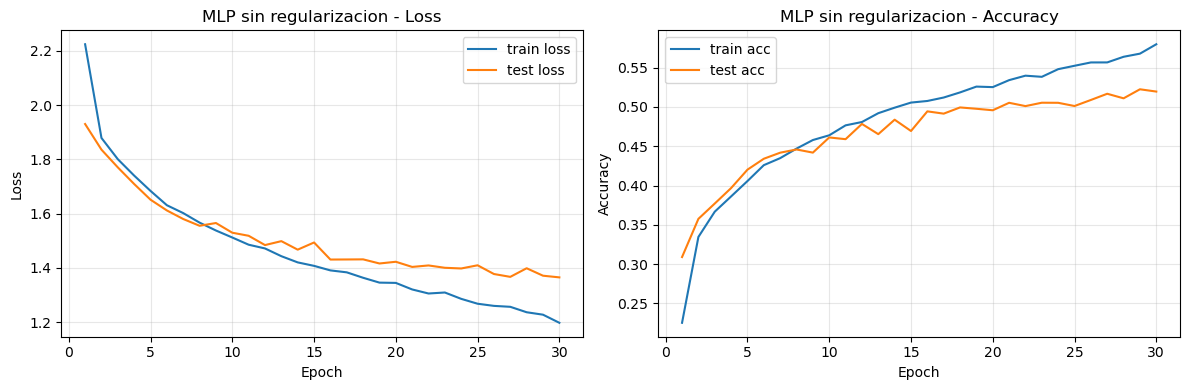

=== MLP sin regularizacion ===
Accuracy          : 0.5196
Precision weighted: 0.5223
Recall weighted   : 0.5196
F1 weighted       : 0.5169
F1 macro          : 0.5169
Classification report:
              precision    recall  f1-score   support

    airplane     0.5694    0.5620    0.5657      1000
  automobile     0.6447    0.6060    0.6247      1000
        bird     0.4704    0.3900    0.4265      1000
         cat     0.3512    0.3740    0.3622      1000
        deer     0.5232    0.3940    0.4495      1000
         dog     0.4068    0.4190    0.4128      1000
        frog     0.5742    0.5650    0.5696      1000
       horse     0.6185    0.5010    0.5536      1000
        ship     0.5618    0.7270    0.6338      1000
       truck     0.5031    0.6580    0.5702      1000

    accuracy                         0.5196     10000
   macro avg     0.5223    0.5196    0.5169     10000
weighted avg     0.5223    0.5196    0.5169     10000



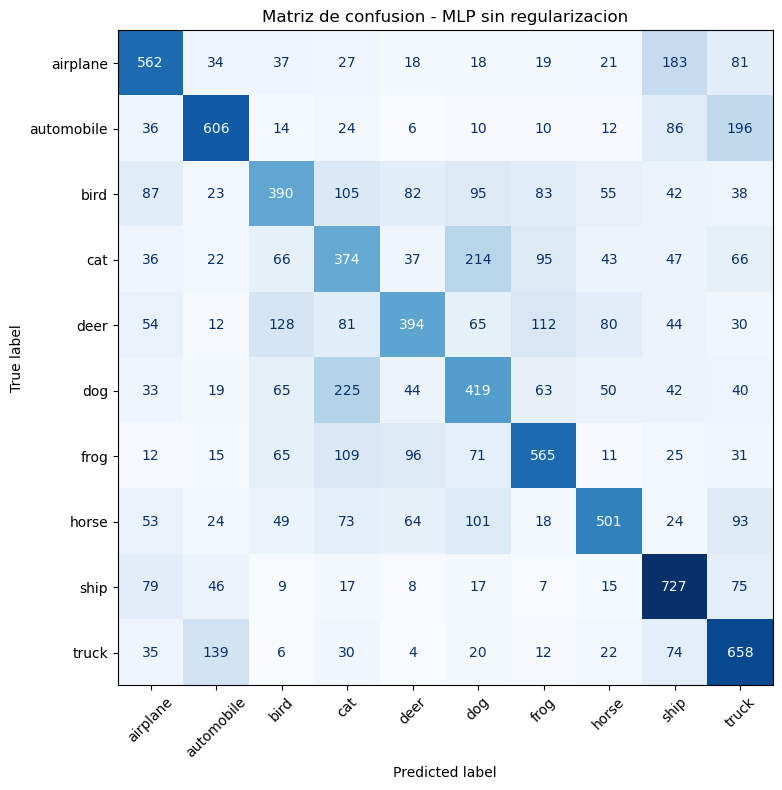

In [ ]:
plot_history(history_base, "MLP sin regularizacion")
evaluate_model(model_base, x_test_mlp, y_test, class_names, "MLP sin regularizacion")
# Aquí tenemos dos gráficas que muestran el MLP sin y con regularización.
# El modelo sin regularización Loss probablemente va a tener buen rendimiento en el conjunto de entrenamiento, pero peor en el conjunto de prueba, sobreajustado.
# Cuando las líneas se separan, quiere decir que tenemos overfitting.
# El modelo sin regularización Accuracy probablemente va a tener buen rendimiento en el conjunto de entrenamiento, pero peor en el conjunto de prueba, sobreajustado.
# Cuando las líneas se separan, quiere decir que tenemos overfitting.

# Debería de aumentar el número de épocas, por que posiblemente pueda entrenar un poco más, pero lo dejamos así para que no tarde mucho.


## 2) Modelo con regularizacion

Se aplican varias tecnicas:
- L2 en capas densas.
- BatchNormalization.
- Dropout.
- EarlyStopping para evitar sobreentrenamiento.


In [9]:
num_classes=10
l2_lambda=1e-3



model_reg = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(512, activation="relu", kernel_regularizer=regularizers.l2(l2_lambda)),
        layers.Dense(256, activation="relu", kernel_regularizer=regularizers.l2(l2_lambda)),
        layers.Dense(num_classes, activation="softmax"),
    ])

model_reg.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
  


model_reg.summary()


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_3 (Dense)             (None, 512)               1573376   
                                                                 
 dense_4 (Dense)             (None, 256)               131328    
                                                                 
 dense_5 (Dense)             (None, 10)                2570      
                                                                 
Total params: 1707274 (6.51 MB)
Trainable params: 1707274 (6.51 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [10]:
EPOCHS = 30
BATCH_SIZE = 1024
history_reg = model_reg.fit(
    x_train_mlp, y_train,
    validation_data=(x_test_mlp, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1,
)


Epoch 1/30
49/49 [==============================] - 2s 34ms/step - loss: 3.1728 - accuracy: 0.2355 - val_loss: 2.6699 - val_accuracy: 0.3319
Epoch 2/30
49/49 [==============================] - 2s 33ms/step - loss: 2.5226 - accuracy: 0.3439 - val_loss: 2.4022 - val_accuracy: 0.3542
Epoch 3/30
49/49 [==============================] - 2s 33ms/step - loss: 2.3071 - accuracy: 0.3658 - val_loss: 2.2076 - val_accuracy: 0.3801
Epoch 4/30
49/49 [==============================] - 2s 32ms/step - loss: 2.1442 - accuracy: 0.3920 - val_loss: 2.0867 - val_accuracy: 0.4038
Epoch 5/30
49/49 [==============================] - 2s 37ms/step - loss: 2.0335 - accuracy: 0.4091 - val_loss: 1.9938 - val_accuracy: 0.4100
Epoch 6/30
49/49 [==============================] - 2s 33ms/step - loss: 1.9412 - accuracy: 0.4232 - val_loss: 1.9354 - val_accuracy: 0.4203
Epoch 7/30
49/49 [==============================] - 2s 32ms/step - loss: 1.8704 - accuracy: 0.4363 - val_loss: 1.8328 - val_accuracy: 0.4418
Epoch 8/30
49

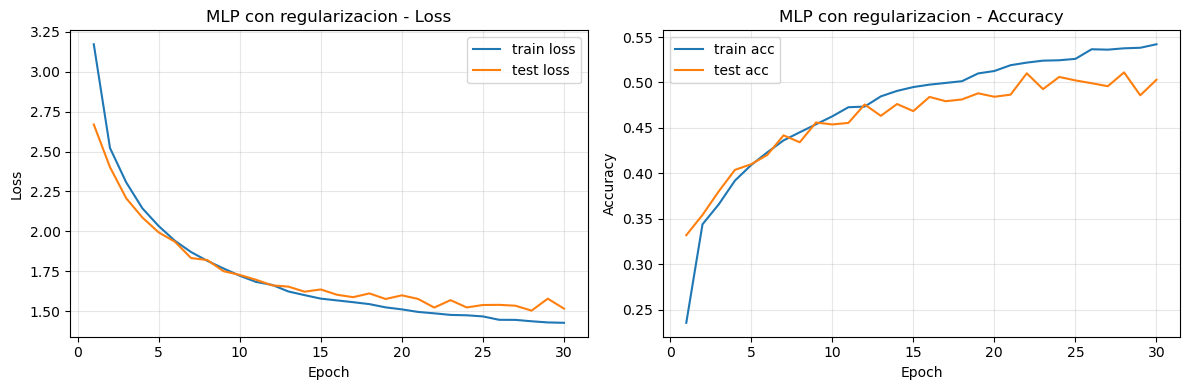

=== MLP con regularizacion ===
Accuracy          : 0.5030
Precision weighted: 0.5228
Recall weighted   : 0.5030
F1 weighted       : 0.5036
F1 macro          : 0.5036
Classification report:
              precision    recall  f1-score   support

    airplane     0.5777    0.5430    0.5598      1000
  automobile     0.6660    0.6240    0.6443      1000
        bird     0.3299    0.5090    0.4003      1000
         cat     0.3314    0.3430    0.3371      1000
        deer     0.5415    0.3000    0.3861      1000
         dog     0.4085    0.4400    0.4237      1000
        frog     0.5286    0.6010    0.5625      1000
       horse     0.6626    0.4830    0.5587      1000
        ship     0.5480    0.7080    0.6178      1000
       truck     0.6336    0.4790    0.5456      1000

    accuracy                         0.5030     10000
   macro avg     0.5228    0.5030    0.5036     10000
weighted avg     0.5228    0.5030    0.5036     10000



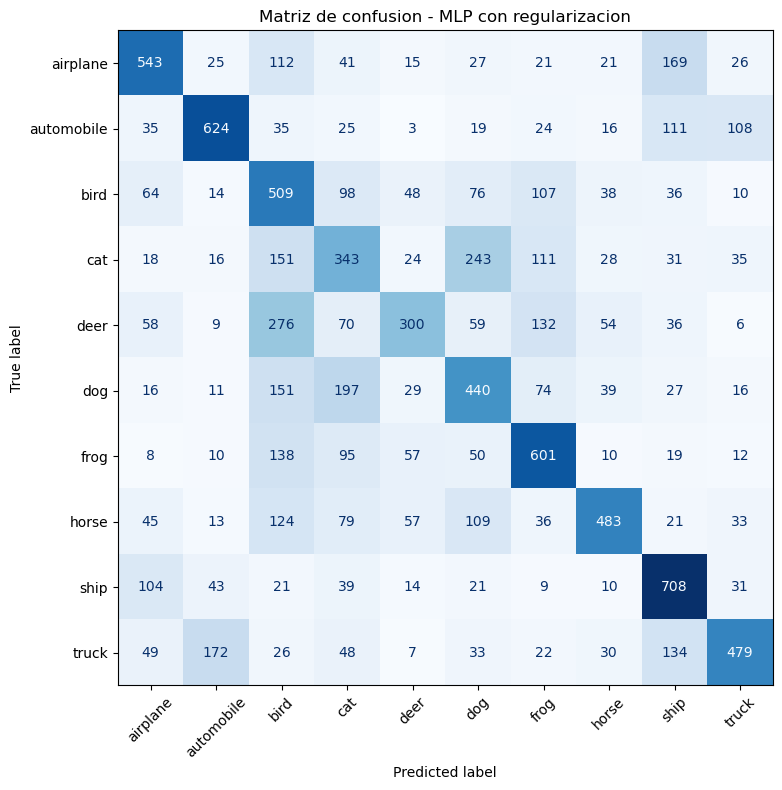

In [11]:
plot_history(history_reg, "MLP con regularizacion")
evaluate_model(model_reg, x_test_mlp, y_test, class_names, "MLP con regularizacion")


## Comparacion final


In [12]:
def final_metrics_row(model, x_test, y_test, name):
    y_pred = np.argmax(model.predict(x_test, verbose=0), axis=1)
    return {
        "Modelo": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision_w": precision_score(y_test, y_pred, average="weighted", zero_division=0),
        "Recall_w": recall_score(y_test, y_pred, average="weighted", zero_division=0),
        "F1_w": f1_score(y_test, y_pred, average="weighted", zero_division=0),
        "F1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
    }

rows = [
    final_metrics_row(model_base, x_test_mlp, y_test, "Sin regularizacion"),
    final_metrics_row(model_reg, x_test_mlp, y_test, "Con regularizacion"),
]

try:
    import pandas as pd
    display(pd.DataFrame(rows).round(4))
except Exception:
    for r in rows:
        print(r)


,Modelo,Accuracy,Precision_w,Recall_w,F1_w,F1_macro
0,Sin regularizacion,0.5196,0.5223,0.5196,0.5169,0.5169
1,Con regularizacion,0.5030,0.5228,0.5030,0.5036,0.5036
